# Data Analytics Project

## Title: Digital Payments & UPI Transaction Analytics

In [26]:
#Step 1: Import Required Libraries

import pandas as pd 
import numpy as np 

In [27]:
#Step 2: Load Dataset

df = pd.read_excel("UPI.xlsx")

In [28]:
#Step 3: Display First 5 Records

df.head()

,Application Name,Date,Customer Initiated Transactions_Volume (Mn),Customer Initiated Transactions_Value (Cr),B2C Transactions_Volume (Mn),B2C Transactions_Value (Cr),B2B Transactions_Volume (Mn),B2B Transactions_Value (Cr),On0us Transactions_Volume (Mn),On0us Transactions_Value (Cr),Total_Volume (Mn),Total_Value (Cr)
0,AIRTEL PAYMENTS BANK APPS,2022-01-01,8.53,2047.45,0.00,0.00,0.0,0.0,4.69,2682.32,13.22,4729.77
1,ALLAHABAD BANK APP,2022-01-01,0.02,7.36,0.00,0.00,0.0,0.0,0.00,0.00,0.02,7.36
2,AMAZON PAY,2022-01-01,73.50,6729.66,0.00,0.00,0.0,0.0,0.00,0.00,73.50,6729.66
3,AU SMALL FINANCE BANK APPS,2022-01-01,0.23,81.15,0.00,0.00,0.0,0.0,0.00,0.00,0.23,81.15
4,AXIS BANK APPS,2022-01-01,6.78,1058.77,40.47,34.25,0.0,0.0,0.00,0.00,47.25,1093.02


In [29]:
#Step 4: Display Last 5 Records

df.tail()

,Application Name,Date,Customer Initiated Transactions_Volume (Mn),Customer Initiated Transactions_Value (Cr),B2C Transactions_Volume (Mn),B2C Transactions_Value (Cr),B2B Transactions_Volume (Mn),B2B Transactions_Value (Cr),On0us Transactions_Volume (Mn),On0us Transactions_Value (Cr),Total_Volume (Mn),Total_Value (Cr)
3788,UNION BANK APPS,2026-03-01,1.00,302.43,0.00,0.00,0.00,0.00,0.0,0.0,1.00,302.43
3789,UNITY SMALL FINANCE BANK APPS,2026-03-01,0.06,15.04,0.00,0.00,0.00,0.00,0.0,0.0,0.06,15.04
3790,WHATSAPP,2026-03-01,130.74,9917.41,0.00,0.00,0.00,0.00,0.0,0.0,130.74,9917.41
3791,YES BANK APPS,2026-03-01,4.29,3959.51,38.79,3568.89,0.22,10.99,0.0,0.0,43.29,7539.40
3792,ZET,2026-03-01,0.03,2.53,0.00,0.00,0.00,0.00,0.0,0.0,0.03,2.53


In [30]:
#Step 5: Check Dataset Information

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3793 entries, 0 to 3792
Data columns (total 12 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Application Name                             3793 non-null   object        
 1   Date                                         3793 non-null   datetime64[ns]
 2   Customer Initiated Transactions_Volume (Mn)  3793 non-null   float64       
 3   Customer Initiated Transactions_Value (Cr)   3793 non-null   float64       
 4   B2C Transactions_Volume (Mn)                 3793 non-null   float64       
 5   B2C Transactions_Value (Cr)                  3793 non-null   float64       
 6   B2B Transactions_Volume (Mn)                 3793 non-null   float64       
 7   B2B Transactions_Value (Cr)                  3793 non-null   float64       
 8   On0us Transactions_Volume (Mn)               3634 non-null   float64       
 9

In [31]:
#Step 6: Check Dataset Shape
df.shape

(3793, 12)

In [32]:
#Step 7: Check Missing Values

df.isnull().sum()

Application Name                                 0
Date                                             0
Customer Initiated Transactions_Volume (Mn)      0
Customer Initiated Transactions_Value (Cr)       0
B2C Transactions_Volume (Mn)                     0
B2C Transactions_Value (Cr)                      0
B2B Transactions_Volume (Mn)                     0
B2B Transactions_Value (Cr)                      0
On0us Transactions_Volume (Mn)                 159
On0us Transactions_Value (Cr)                  222
Total_Volume (Mn)                                0
Total_Value (Cr)                                 0
dtype: int64

In [33]:
#Step 8: Drop On0us Columns

df.drop(columns=[
    "On0us Transactions_Volume (Mn)",
    "On0us Transactions_Value (Cr)"
], inplace=True) 

In [34]:
#To check if those two columns have been removed.

df.columns  

Index(['Application Name', 'Date',
       'Customer Initiated Transactions_Volume (Mn)',
       'Customer Initiated Transactions_Value (Cr)',
       'B2C Transactions_Volume (Mn)', 'B2C Transactions_Value (Cr)',
       'B2B Transactions_Volume (Mn)', 'B2B Transactions_Value (Cr)',
       'Total_Volume (Mn)', 'Total_Value (Cr)'],
      dtype='object')

In [35]:
#Step 9: Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [36]:
#Step 10: Rename Column Names

df.rename(columns={
    "Application Name":"App_Name",
    "Customer Initiated Transactions_Volume (Mn)":"Customer_Volume(Mn)",
    "Customer Initiated Transactions_Value (Cr)":"Customer_Value(Cr)",
    "B2C Transactions_Volume (Mn)":"B2C_Volume(Mn)",
    "B2C Transactions_Value (Cr)":"B2C_Value(Cr)",
    "B2B Transactions_Volume (Mn)":"B2B_Volume(Mn)",
    "B2B Transactions_Value (Cr)":"B2B_Value(Cr)",
    "Total_Volume (Mn)":"Total_Volume(Mn)",
    "Total_Value (Cr)":"Total_Value(Cr)"
}, inplace=True)

In [37]:
#Step 11: Verify Renamed Columns

df.columns

Index(['App_Name', 'Date', 'Customer_Volume(Mn)', 'Customer_Value(Cr)',
       'B2C_Volume(Mn)', 'B2C_Value(Cr)', 'B2B_Volume(Mn)', 'B2B_Value(Cr)',
       'Total_Volume(Mn)', 'Total_Value(Cr)'],
      dtype='object')

In [38]:
#Step 13: Create Month_Name Column

df["Month_Name"] = df["Date"].dt.month_name() 

In [39]:
#Step 14: Create Quarter Column

df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

In [40]:
#Step 15: Create Year Column

df["Year"] = df["Date"].dt.year

In [41]:
# Step 16: Verify Newly Added Columns

df.head()


,App_Name,Date,Customer_Volume(Mn),Customer_Value(Cr),B2C_Volume(Mn),B2C_Value(Cr),B2B_Volume(Mn),B2B_Value(Cr),Total_Volume(Mn),Total_Value(Cr),Month_Name,Quarter,Year
0,AIRTEL PAYMENTS BANK APPS,2022-01-01,8.53,2047.45,0.00,0.00,0.0,0.0,13.22,4729.77,January,Q1,2022
1,ALLAHABAD BANK APP,2022-01-01,0.02,7.36,0.00,0.00,0.0,0.0,0.02,7.36,January,Q1,2022
2,AMAZON PAY,2022-01-01,73.50,6729.66,0.00,0.00,0.0,0.0,73.50,6729.66,January,Q1,2022
3,AU SMALL FINANCE BANK APPS,2022-01-01,0.23,81.15,0.00,0.00,0.0,0.0,0.23,81.15,January,Q1,2022
4,AXIS BANK APPS,2022-01-01,6.78,1058.77,40.47,34.25,0.0,0.0,47.25,1093.02,January,Q1,2022


In [42]:
#Step 17: Check Final Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3793 entries, 0 to 3792
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   App_Name             3793 non-null   object        
 1   Date                 3793 non-null   datetime64[ns]
 2   Customer_Volume(Mn)  3793 non-null   float64       
 3   Customer_Value(Cr)   3793 non-null   float64       
 4   B2C_Volume(Mn)       3793 non-null   float64       
 5   B2C_Value(Cr)        3793 non-null   float64       
 6   B2B_Volume(Mn)       3793 non-null   float64       
 7   B2B_Value(Cr)        3793 non-null   float64       
 8   Total_Volume(Mn)     3793 non-null   float64       
 9   Total_Value(Cr)      3793 non-null   float64       
 10  Month_Name           3793 non-null   object        
 11  Quarter              3793 non-null   object        
 12  Year                 3793 non-null   int32         
dtypes: datetime64[ns](1), float64(8),

In [43]:
#Step 18: Check Final Shape

df.shape

(3793, 13)

In [44]:
#Step 19: Save Clean Dataset

df.to_excel("cleaned_upi_transactions.xlsx", index=False)

# EDA -- (Exploratory Data Analysis)

In [45]:
# Step 1: Statistical Summary

df.describe() 


,Date,Customer_Volume(Mn),Customer_Value(Cr),B2C_Volume(Mn),B2C_Value(Cr),B2B_Volume(Mn),B2B_Value(Cr),Total_Volume(Mn),Total_Value(Cr),Year
count,3793,3793.000000,3.793000e+03,3793.000000,3793.000000,3793.000000,3793.000000,3793.000000,3.793000e+03,3793.000000
mean,2024-03-21 17:24:47.266016256,169.990859,2.485402e+04,1.368321,80.673174,0.086839,78.236098,172.179594,2.574158e+04,2023.782494
min,2022-01-01 00:00:00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e-02,2022.000000
25%,2023-03-01 00:00:00,0.110000,2.592000e+01,0.000000,0.000000,0.000000,0.000000,0.110000,2.621000e+01,2023.000000
50%,2024-04-01 00:00:00,0.810000,1.561500e+02,0.000000,0.000000,0.000000,0.000000,0.870000,1.650700e+02,2024.000000
75%,2025-05-01 00:00:00,7.350000,1.061610e+03,0.000000,0.000000,0.000000,0.000000,8.010000,1.121410e+03,2025.000000
max,2026-03-01 00:00:00,10503.810000,1.448287e+06,128.830000,11080.460000,45.530000,12841.440000,10503.810000,1.448287e+06,2026.000000
std,NaN,945.398945,1.364595e+05,9.705953,680.162197,0.948889,750.712010,946.065809,1.381379e+05,1.247525


In [50]:
#Step 2: yearly Transaction Trend

yearly_trend = df.groupby("Year")[["Total_Volume(Mn)", "Total_Value(Cr)"]].sum()
yearly_trend

,Total_Volume(Mn),Total_Value(Cr)
Year,,
2022,75270.64,16400960.85
2023,119017.40,18544893.34
2024,170824.47,24616912.54
2025,224238.20,29676740.81
2026,63726.49,8398318.54


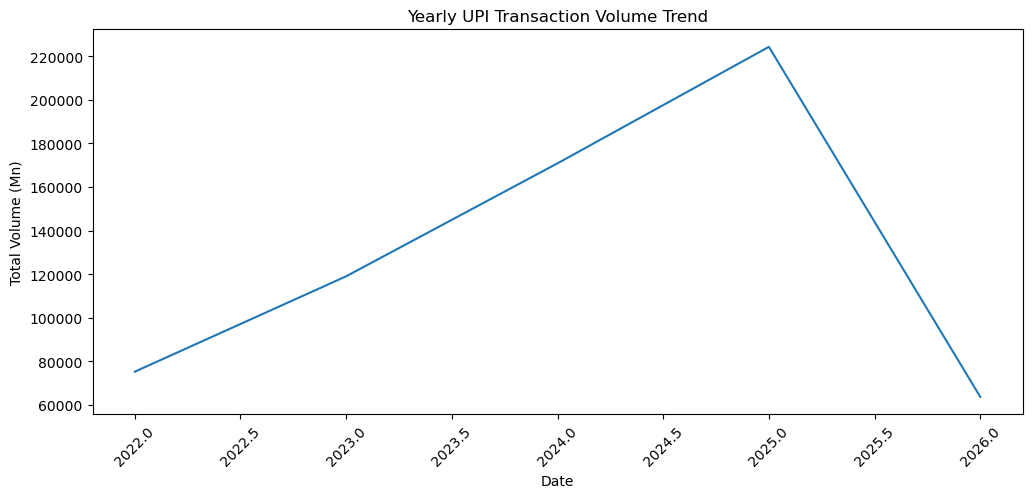

In [51]:
# EDA - Step 3: yearly Transaction Volume Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(yearly_trend.index, yearly_trend["Total_Volume(Mn)"])

plt.title("Yearly UPI Transaction Volume Trend")
plt.xlabel("Date")
plt.ylabel("Total Volume (Mn)")
*
plt.xticks(rotation=45)

plt.show()

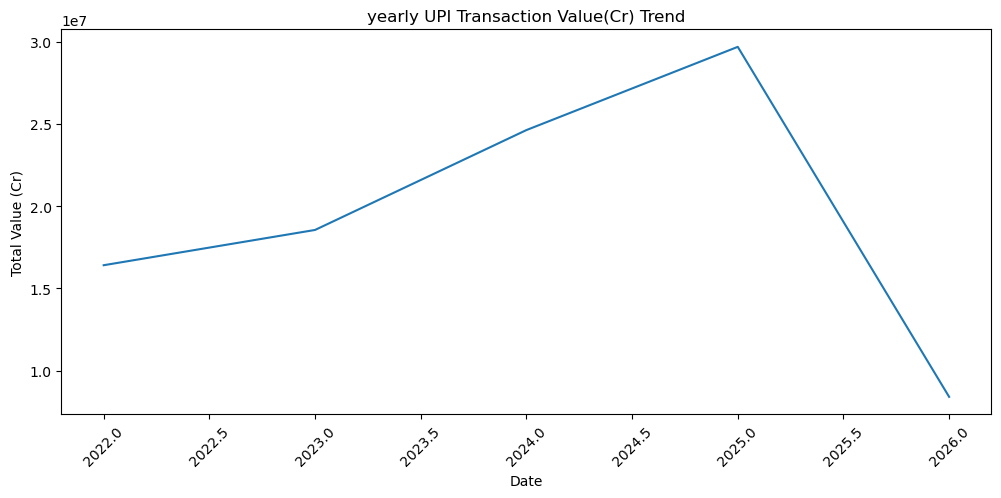

In [55]:
#Step 4: Yearly Transaction Value Trend

plt.figure(figsize=(12,5))

plt.plot(yearly_trend.index, yearly_trend["Total_Value(Cr)"])

plt.title("yearly UPI Transaction Value(Cr) Trend")
plt.xlabel("Date")
plt.ylabel("Total Value (Cr)")

plt.xticks(rotation=45)

plt.show()

In [57]:
#Step 6 — Quarter-wise Analysis

quarterly_growth = df.groupby("Quarter")[["Total_Volume(Mn)", "Total_Value(Cr)"]].sum()

quarterly_growth

,Total_Volume(Mn),Total_Value(Cr)
Quarter,,
Q1,191737.19,31324893.46
Q2,140585.62,20757845.25
Q3,153429.45,21617415.60
Q4,167324.94,23937671.77


In [58]:
#Step 7 — Top 10 Apps by Transaction Volume

top_volume = (
    df.groupby("App_Name")["Total_Volume(Mn)"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_volume

App_Name
PHONEPE                    308415.47
GOOGLE PAY                 233380.36
PAYTM PAYMENTS BANK APP     29253.03
PAYTM                       28066.20
NAVI                         8319.45
CRED                         4870.60
AXIS BANK APPS               4595.93
PAYTM (OCL)                  4444.73
SUPER.MONEY                  3814.79
AMAZON PAY                   3680.22
Name: Total_Volume(Mn), dtype: float64

In [59]:
#Step 8 — Top 10 Apps by Transaction Value

top_value = (
    df.groupby("App_Name")["Total_Value(Cr)"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_value

App_Name
PHONEPE                    47441486.54
GOOGLE PAY                 33269964.17
PAYTM PAYMENTS BANK APP     3532956.33
PAYTM                       3043031.03
CRED                        1932403.80
ICICI BANK APPS             1757960.18
HDFC BANK APPS              1240602.47
HSBC BANK APP                580307.57
YES BANK APPS                531852.89
BHIM                         528686.93
Name: Total_Value(Cr), dtype: float64

In [61]:
#Step 9 — Transaction Type Analysis

transaction_type = df[
    ["Customer_Volume(Mn)", "B2C_Volume(Mn)", "B2B_Volume(Mn)"] 
].sum()

transaction_type

Customer_Volume(Mn)    644775.33
B2C_Volume(Mn)           5190.04
B2B_Volume(Mn)            329.38
dtype: float64